In [3]:
from scipy import *
import matplotlib.pyplot as plt
import numpy as np
import random 


In [4]:
### Deterministic 1-locus selection model: recursion equation
# args:
# q   : Frequency of A2 allele  (numeric, between 0,1)
# w_1 : Relative fitness of A1A1 genotype (numeric, somewhere between 0 & 1.5)
# w_2 : Relative fitness of A1A2 genotype (numeric, somewhere between 0 & 1.5)
# w_3 : Relative fitness of A2A2 genotype (numeric, somewhere between 0 & 1.5)
# u   : Mutation rate from A1 --> A2 (numeric, usually small, e.g., 0.0001)
def qNext(q, w_1, w_2, w_3, u):
    q = q + (1 - q)*u
    return (q**2 * w_3 + (1 - q)*q*w_2) / ((1 - q)**2 * w_1 + 2*(1 - q)*q * w_2 + q**2 * w_3)

In [5]:
qNext(q = 0., w_1 = 1, w_2 = 1.05, w_3 = 1.1, u=0)


0.0

In [6]:
### Function to generate time series of deterministic allele frequencies
def determTraj(q0, w_1, w_2, w_3, nGen, u=0):

    q    = [0] * nGen # storage array
    q[0] = q0 # initial frequency
    
    # loop over time steps to calculate allele frequency trajectory
    for t in range(1,nGen):
        q[t] = qNext(q=q[t-1], w_1=w_1, w_2=w_2, w_3=w_3, u=u)

    # return allel freq. trajectory
    return np.array(q)



In [7]:
### Function to plot deterministic trajectory
def plotDetermTraj(q0, w_1, w_2, w_3, nGen, u=0, plotP=False, yLim=[0,1]):
    
    # make data
    q = determTraj(q0 = q0, w_1 = w_1, w_2 = w_2, w_3 = w_3, u = u, nGen = nGen)
    time = np.arange(start=0, stop=nGen, step=1)

    # plot options
    fig,ax=plt.subplots()
    ax.set_xlim([0, nGen])
    ax.set_ylim(yLim)
    ax.set_xlabel('Generations')
    ax.set_ylabel('Frequency of $A_2$ allele ($q$)')

    # make plot
    if plotP:
        plt.plot(time, 1-q, color='dodgerblue', ls='-', lw=2)
    else:
        plt.plot(time, q, color='dodgerblue', ls='-', lw=2)

    plt.show()

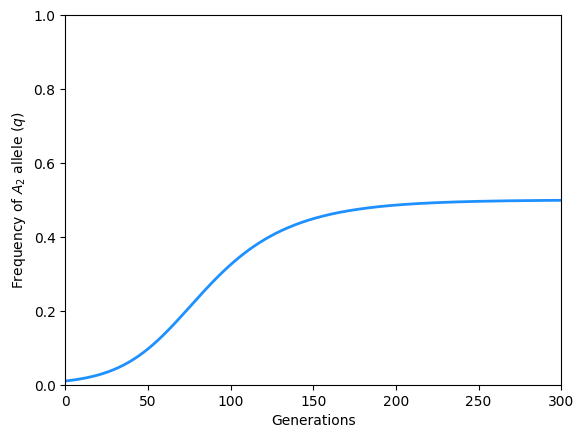

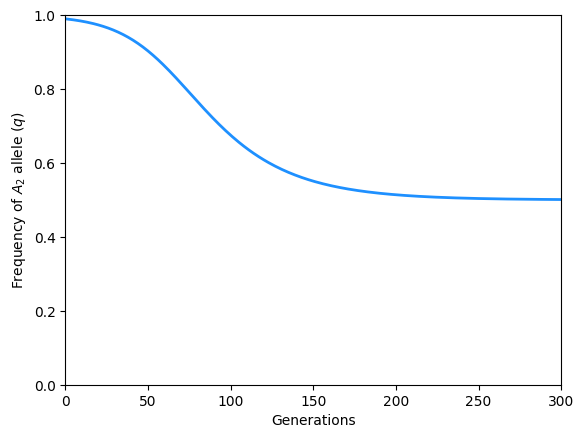

In [13]:
plotDetermTraj(q0=0.01, w_1=0.95, w_2=1, w_3=0.95, nGen=300, plotP=False)

plotDetermTraj(q0=0.01, w_1=0.95, w_2=1, w_3=0.95, nGen=300, plotP=True)


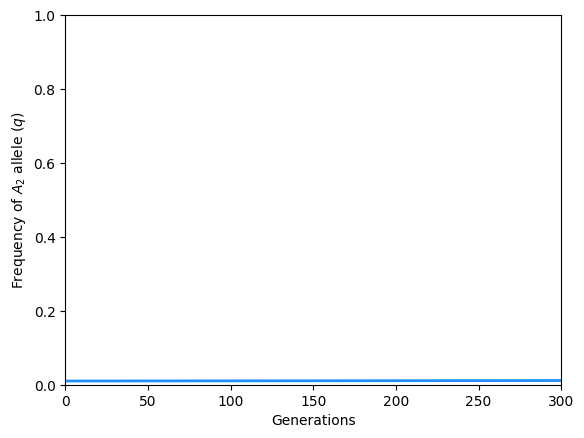

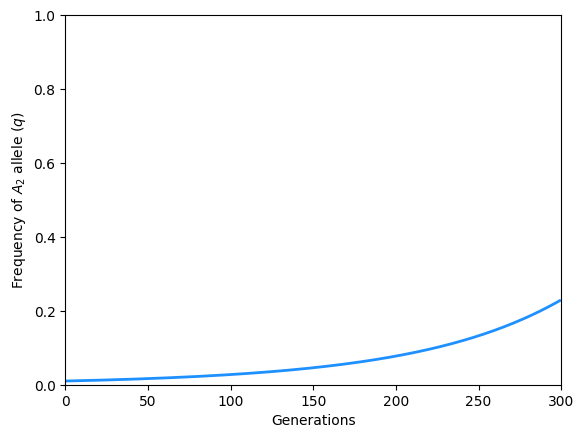

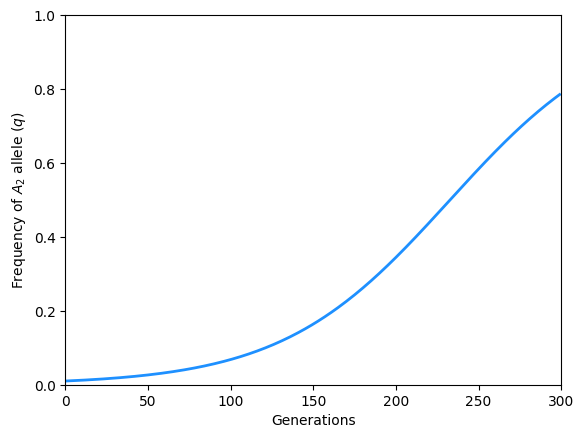

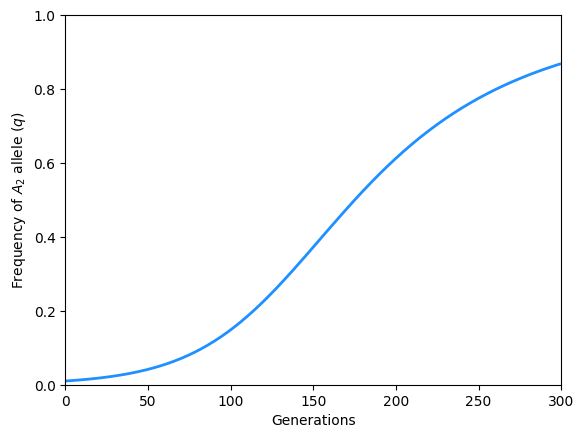

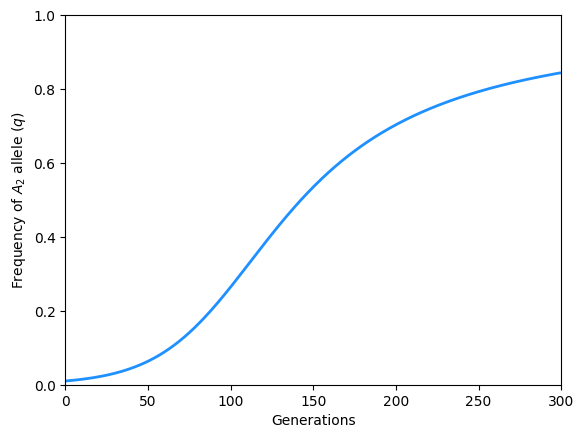

In [33]:

plotDetermTraj(q0=0.01, w_1=1.0, w_2=1.0, w_3=1.04, nGen=300, plotP=False)
plotDetermTraj(q0=0.01, w_1=1.0, w_2=1.01, w_3=1.04, nGen=300, plotP=False)
plotDetermTraj(q0=0.01, w_1=1.0, w_2=1.02, w_3=1.04, nGen=300, plotP=False)
plotDetermTraj(q0=0.01, w_1=1.0, w_2=1.03, w_3=1.04, nGen=300, plotP=False)
plotDetermTraj(q0=0.01, w_1=1.0, w_2=1.04, w_3=1.04, nGen=300, plotP=False)

### What parameters are we adjusting?

We are adjusting the parameters `w_1`, `w_2`, and `w_3` in the function `plotDetermTraj`. These parameters represent weights that influence the behavior of the deterministic trajectory being plotted.

In [15]:
def plotDetermTrajMulti(w_1, w_2, w_3, nGen, u = 0, n_lines=20, clrmp = 'managua', plotP=False, plotPHat = False):
    cmap = plt.colormaps[clrmp]
    # Take colors at regular intervals spanning the colormap.
    colors = cmap(np.linspace(0, 1, n_lines))

    # Calculate equilibrium    
    if w_1 == w_3:
        pHat = 1/2
    else:
        h = (w_2-1)/(w_3-1)
        pHat = (h - 1)/(2*h - 1)
    
    fig,ax=plt.subplots()
    ax.set_xlim([0, nGen])
    ax.set_ylim([0, 1])
    ax.set_xlabel('Generations')
    if plotP:
        ax.set_ylabel('Frequency of $A_1$ allele ($p$)')
    else:
        ax.set_ylabel('Frequency of $A_2$ allele ($q$)')
            
    time = np.arange(start=0, stop=nGen, step=1)
    qInits = np.linspace(0, 1, n_lines)
    for i in range(n_lines):
        q = determTraj(q0 = qInits[i], w_1 = w_1, w_2 = w_2, w_3 = w_3, u = u, nGen = nGen)
        ax.plot(time, q, color=colors[i], ls='-', lw=2)
        #plt.pause(0.01)

    if(plotPHat):
        if(0< pHat < 1):
            plt.axhline(y = 1 - pHat, color = 'red', linestyle = '--') 
    
    plt.show()




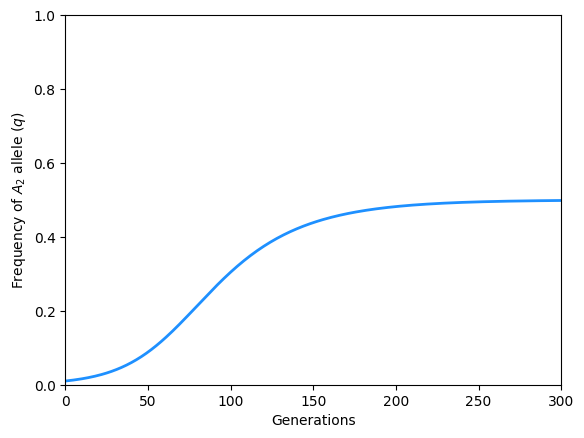

In [17]:
plotDetermTraj(q0=0.01, w_1=1.0, w_2=1.05, w_3=1, nGen=300, plotP=False)

## Exercise 2

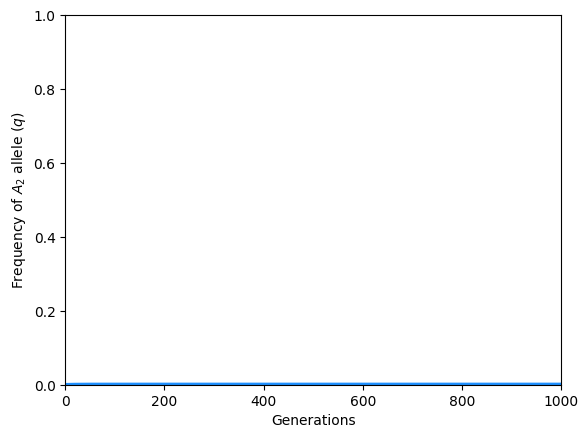

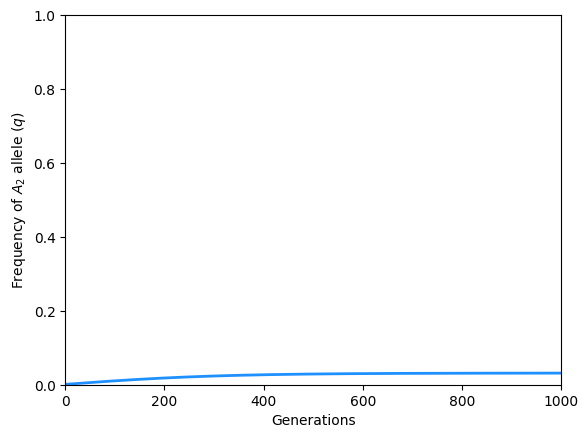

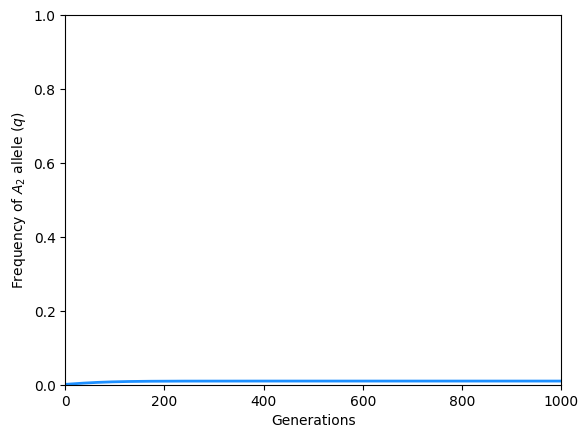

In [34]:
plotDetermTraj(q0 = 0.001, w_1 = 1, w_2 = 0.95, w_3 = 0.9, u=0.0001,nGen = 1000, plotP=False)
plotDetermTraj(q0 = 0.001, w_1 = 1, w_2 = 1.0, w_3 = 0.9, nGen = 1000, u=0.0001,plotP=False)
plotDetermTraj(q0 = 0.001, w_1 = 1, w_2 = 1.0, w_3 = 0, nGen = 1000, u=0.0001,plotP=False)

Discuss some important conclusions you can draw from these results in relation to disease genetics in your report. e.g., why do well known, deadly, congenital diseases persist in humans?
Where are rare (and often deleterious) alleles often found?
Why might many deleterious alleles often be strongly recessive?
What are some implications for human health?


Answer: the pe

In [ ]:
exec(open('./Allele-A1-functions.py').read())

## Exercise 3: Genetic Drift

In [ ]:
plotWFSims(q0=0.5, w_1=1, w_2=1, w_3=1, nGen=100, N=100, n_lines=50)